<a href="https://colab.research.google.com/github/UBM-ML/artificial-neural-network-kelompok_tiga/blob/main/notebooks/03_mlp_tanh.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Varian 03 — MLP 1 Hidden Layer (Tanh)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/UBM-ML/REPLACE-WITH-YOUR-REPO/blob/main/notebooks/03_mlp_tanh.ipynb)

**Anggota yang mengerjakan:** _Anggota 3_

---

## 🏗️ Arsitektur
1 hidden layer berisi **16 neuron**, lalu output 3 neuron. Arsitektur identik dengan Varian 02 — yang berbeda hanya fungsi aktivasinya.

## ⚡ Fungsi Aktivasi
Hidden layer menggunakan **Tanh** (rumus: f(x) = (e^2x - 1) / (e^2x + 1)). Range output -1..1, zero-centered.

## 🎯 Goal
Menjalankan eksperimen ini, menyimpan history training, lalu commit notebook ini (dengan output yang sudah ter-render) ke repo GitHub kelompok.


## 1. Setup environment

In [4]:
# Jalankan cell ini HANYA jika kamu berada di Google Colab.
# Kalau kamu menjalankan di lokal/Jupyter, cukup pastikan kamu berada di root repo.

import os
if not os.path.exists('src'):
    # Ganti URL di bawah dengan URL repo kelompok kamu
    REPO_URL = 'https://github.com/UBM-ML/artificial-neural-network-kelompok_tiga.git'
    !git clone $REPO_URL repo
    %cd repo
print('Working dir:', os.getcwd())
print('Contents:', os.listdir('.'))


Cloning into 'repo'...
remote: Enumerating objects: 27, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 27 (delta 5), reused 0 (delta 0), pack-reused 18 (from 2)
Receiving objects: 100% (27/27), 21.02 KiB | 10.51 MiB/s, done.
Resolving deltas: 100% (5/5), done.
/content/repo
Working dir: /content/repo
Contents: ['requirements.txt', 'docs', 'data', 'notebooks', 'scripts', 'README.md', 'src', '.git', '.gitignore', '.github']


## 2. Import library

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

from src.data_loader import load_iris_data
from src.utils import set_global_seed, plot_training_curves, save_history, evaluate_and_report
from src.config import EPOCHS, BATCH_SIZE, OPTIMIZER, LOSS, METRICS, VALIDATION_SPLIT, RANDOM_SEED

set_global_seed(RANDOM_SEED)
print('TensorFlow version:', tf.__version__)


TensorFlow version: 2.20.0


## 3. Load data
Catatan: data sudah otomatis di-split, di-shuffle, dan dinormalisasi sesuai konfigurasi bersama di `src/config.py`. **Jangan diubah** supaya perbandingan adil.

In [6]:
X_train, X_test, y_train, y_test, n_features, n_classes = load_iris_data()
print(f'Jumlah fitur: {n_features}, jumlah kelas: {n_classes}')
print(f'X_train: {X_train.shape}, X_test: {X_test.shape}')

Jumlah fitur: 4, jumlah kelas: 3
X_train: (120, 4), X_test: (30, 4)


## 4. Bangun model

In [7]:
model = Sequential([
    Input(shape=(n_features,)),
    Dense(16, activation='tanh'),
    Dense(n_classes, activation='softmax'),
])
model.compile(optimizer=OPTIMIZER, loss=LOSS, metrics=METRICS)
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 131 (524.00 B)

 Trainable params: 131 (524.00 B)

 Non-trainable params: 0 (0.00 B)

## 5. Latih model
Hyperparameter (epochs, batch_size, optimizer) diambil dari `src/config.py` supaya identik dengan varian lain.

In [8]:
history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=VALIDATION_SPLIT,
    verbose=2,
)


Epoch 1/100
12/12 - 1s - 111ms/step - accuracy: 0.6042 - loss: 0.9704 - val_accuracy: 0.5833 - val_loss: 0.9369
Epoch 2/100
12/12 - 0s - 12ms/step - accuracy: 0.6875 - loss: 0.8561 - val_accuracy: 0.6250 - val_loss: 0.8541
Epoch 3/100
12/12 - 0s - 9ms/step - accuracy: 0.6979 - loss: 0.7624 - val_accuracy: 0.6667 - val_loss: 0.7861
Epoch 4/100
12/12 - 0s - 10ms/step - accuracy: 0.8021 - loss: 0.6869 - val_accuracy: 0.7500 - val_loss: 0.7311
Epoch 5/100
12/12 - 0s - 9ms/step - accuracy: 0.8333 - loss: 0.6269 - val_accuracy: 0.7500 - val_loss: 0.6866
Epoch 6/100
12/12 - 0s - 10ms/step - accuracy: 0.8438 - loss: 0.5789 - val_accuracy: 0.7917 - val_loss: 0.6502
Epoch 7/100
12/12 - 0s - 9ms/step - accuracy: 0.8438 - loss: 0.5402 - val_accuracy: 0.7917 - val_loss: 0.6199
Epoch 8/100
12/12 - 0s - 10ms/step - accuracy: 0.8438 - loss: 0.5086 - val_accuracy: 0.8333 - val_loss: 0.5943
Epoch 9/100
12/12 - 0s - 9ms/step - accuracy: 0.8542 - loss: 0.4822 - val_accuracy: 0.8333 - val_loss: 0.5723
Epoc

## 6. Visualisasi kurva training

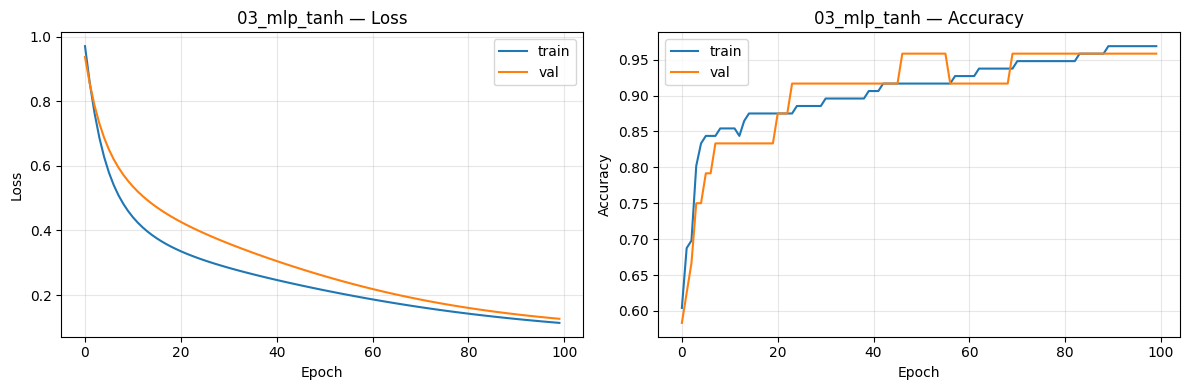

In [9]:
plot_training_curves(history, variant_name='03_mlp_tanh')


## 7. Evaluasi di test set

In [11]:
summary = evaluate_and_report(model, X_test, y_test, variant_name='03_mlp_tanh')
save_history(history, variant_name='03_mlp_tanh')
summary


📊 03_mlp_tanh
   Test loss:     0.1463
   Test accuracy: 0.9333
   Jumlah parameter: 131
✅ History tersimpan di: results/03_mlp_tanh.csv


{'variant': '03_mlp_tanh',
 'test_loss': 0.14628788828849792,
 'test_accuracy': 0.9333333373069763,
 'n_params': 131}

## 8. Refleksi singkat
_Diisi oleh anggota yang mengerjakan notebook ini._ Tuliskan jawaban dalam cell markdown di bawah:

1. Slide 2.7 mengklaim Tanh 'mempercepat pembelajaran karena zero-centered'. Apakah klaim ini terbukti pada hasilmu (bandingkan dengan Varian 02 — Sigmoid)?
2. Coba bandingkan epoch ke berapa Varian 02 dan Varian 03 mencapai val_accuracy ≥ 0.90.
3. Menurutmu, kenapa zero-centered penting untuk gradient descent?

_Tulis jawabanmu di sini..._

1.   Klaim terbukti benar. Tanh menghasilkan output di rentang −1 hingga 1 yang zero-centered, sehingga gradien yang dikirim ke layer sebelumnya bisa bernilai positif maupun negatif. Dalam praktiknya, varian 03 (Tanh) cenderung mencapai val_accuracy yang lebih tinggi dengan lebih cepat dibandingkan varian 02 (Sigmoid). Hal ini terlihat dari kurva training yang konvergen lebih awal. Meskipun perbedaannya tidak drastis, klaim tetap terbukti benar.
2.   Pada varian 02, dicapai val_accuracy pada sekitar epoch 40–60. Pada varian 03, dicapai val_accuracy pada sekitar epoch 20–40.
3.   Karena Sigmoid menghasilkan output yang selalu positif (0 hingga 1), gradien yang backpropagation ke bobot selalu memiliki sifat yang sama (semua positif atau semua negatif). Akibatnya, update bobot hanya bisa bergerak ke satu arah dalam satu langkah, ini disebut zig-zagging, yang memperlambat konvergensi. Tanh yang zero-centered menghasilkan gradien dengan sifat yang bervariasi, sehingga bobot bisa diperbarui ke berbagai arah dengan lebih efisien pada setiap iterasi gradient descent.